# Policy comparison

Loads every `pulls-*.csv` in `logs/`, plots cumulative reward and oracle-agreement over time.

In [34]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ORACLE_LABEL = 'oracle'

candidates = [Path.cwd() / 'logs', Path.cwd() / 'RMAB_cwh' / 'logs', Path('C:/dev/cw_or_env/RMAB_cwh/logs')]
LOG_DIR = next((p for p in candidates if p.exists()), None)
if LOG_DIR is None:
    raise RuntimeError(f'no logs dir found. cwd={Path.cwd()}, tried={candidates}')
print(f'LOG_DIR = {LOG_DIR}')

def label_from(path: Path) -> str:
    parts = path.stem.split('-')
    return 'llm' if len(parts) == 2 else '-'.join(parts[1:-1])

def policy_style(label):
    if label == ORACLE_LABEL:
        return {'linewidth': 2.5, 'color': 'black'}
    if label.startswith('gpt') or label.startswith('o4') or label == 'llm':
        return {'linewidth': 2.8}
    return {'linewidth': 1.2, 'alpha': 0.8}

files = sorted(LOG_DIR.glob('pulls-*.csv'))
print(f'found {len(files)} csv(s):')
for p in files:
    print(f'  {p.name}')
if not files:
    raise RuntimeError(f'no pulls-*.csv files in {LOG_DIR}')

dfs = {label_from(p): pd.read_csv(p) for p in files}
print()
for label, df in dfs.items():
    if len(df):
        print(f'{label:14s}  pulls={len(df):4d}  final={df["total_value"].iloc[-1]:.4f}')
    else:
        print(f'{label:14s}  empty')

LOG_DIR = c:\dev\cw_or_env\RMAB_cwh\logs
found 10 csv(s):
  pulls-gpt-4o-1-20260425T160629Z.csv
  pulls-gpt-4o-2-20260425T163506Z.csv
  pulls-gpt-4o-mini-20260425T154007Z.csv
  pulls-gpt-5.4-mini-20260425T162650Z.csv
  pulls-greedy-20260425T154837Z.csv
  pulls-oracle-20260425T154837Z.csv
  pulls-random-20260425T154832Z.csv
  pulls-random-20260425T154837Z.csv
  pulls-roundrobin-20260425T154837Z.csv
  pulls-sliding_ucb-20260425T154837Z.csv

gpt-4o-1        pulls= 175  final=168.3777
gpt-4o-2        pulls= 190  final=131.8941
gpt-4o-mini     pulls= 200  final=141.0597
gpt-5.4-mini    pulls= 200  final=152.5181
greedy          pulls= 200  final=170.9683
oracle          pulls= 200  final=434.3148
random          pulls= 200  final=202.7664
roundrobin      pulls= 200  final=161.9478
sliding_ucb     pulls= 200  final=300.2336


## 1. Cumulative reward across pulls

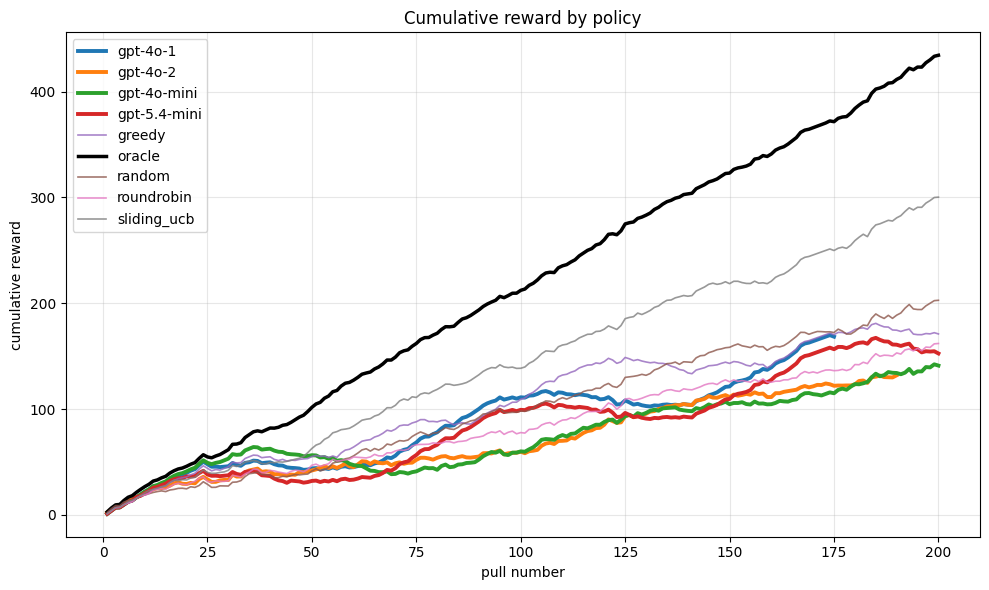

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, df in dfs.items():
    if len(df) == 0:
        continue
    ax.plot(df['pull_number'], df['total_value'], label=label, **policy_style(label))
ax.set_xlabel('pull number')
ax.set_ylabel('cumulative reward')
ax.set_title('Cumulative reward by policy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Cumulative count of pulls that hit the oracle's machine

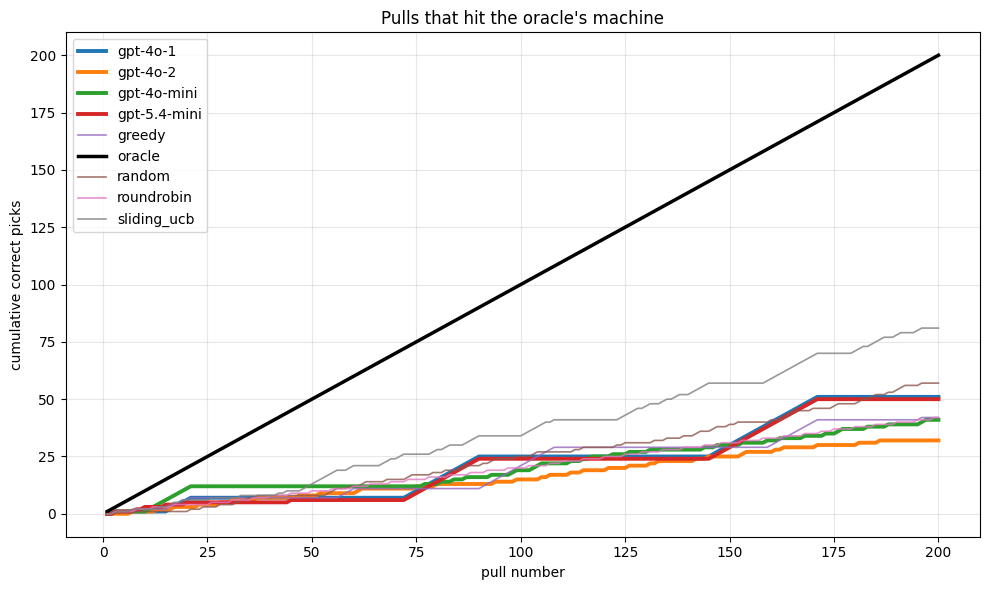

In [36]:
if ORACLE_LABEL not in dfs:
    raise RuntimeError(f'no oracle csv found in {LOG_DIR}')

oracle_picks = dfs[ORACLE_LABEL].set_index('pull_number')['pulled_machine']

fig, ax = plt.subplots(figsize=(10, 6))
for label, df in dfs.items():
    if len(df) == 0:
        continue
    picks = df.set_index('pull_number')['pulled_machine'].reindex(oracle_picks.index)
    correct = (picks == oracle_picks).fillna(False).cumsum()
    ax.plot(correct.index, correct.values, label=label, **policy_style(label))
ax.set_xlabel('pull number')
ax.set_ylabel('cumulative correct picks')
ax.set_title("Pulls that hit the oracle's machine")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In [37]:
rows = []
for label, df in dfs.items():
    if len(df) == 0:
        continue
    picks = df.set_index('pull_number')['pulled_machine'].reindex(oracle_picks.index)
    n = picks.notna().sum()
    correct = (picks == oracle_picks).sum()
    rows.append({
        'policy': label,
        'pulls': len(df),
        'final_total': df['total_value'].iloc[-1],
        'oracle_match_rate': correct / n if n else float('nan'),
    })
summary = pd.DataFrame(rows).sort_values('final_total', ascending=False)
summary

,policy,pulls,final_total,oracle_match_rate
5,oracle,200,434.314757,1.000000
8,sliding_ucb,200,300.233610,0.405000
6,random,200,202.766352,0.285000
4,greedy,200,170.968332,0.210000
0,gpt-4o-1,175,168.377740,0.291429
7,roundrobin,200,161.947788,0.210000
3,gpt-5.4-mini,200,152.518115,0.250000
2,gpt-4o-mini,200,141.059689,0.205000
1,gpt-4o-2,190,131.894100,0.168421


,policy,turns,pulls,bash_calls,final_score
0,oracle,200,200,0,434.314757
1,sliding_ucb,200,200,0,300.233610
2,random,200,200,0,202.766352
3,greedy,200,200,0,170.968332
4,gpt-4o-1,139,175,7,168.377740
5,roundrobin,200,200,0,161.947788
6,gpt-5.4-mini,192,200,0,152.518115
7,gpt-4o-mini,45,200,0,141.059689
8,gpt-4o-2,442,190,436,131.894100


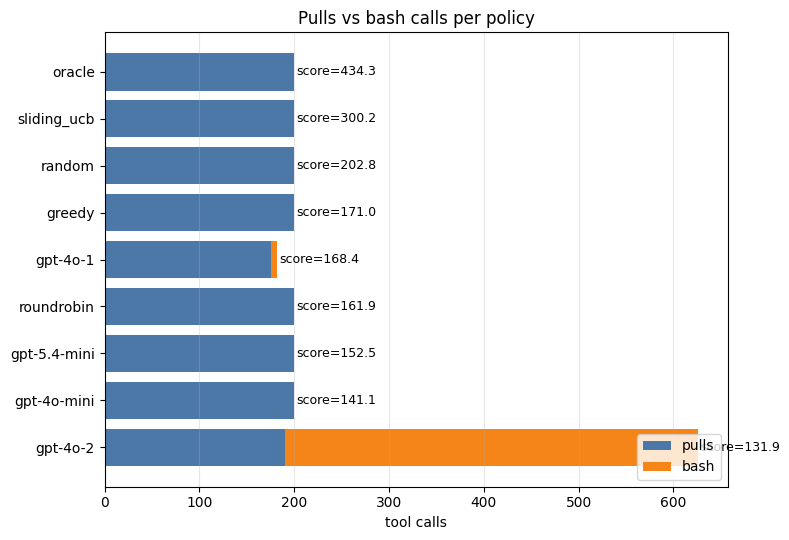

In [38]:
import json

def find_episode(label):
    matches = sorted(LOG_DIR.glob(f'episode-{label}-*.jsonl'))
    return matches[-1] if matches else None

rows = []
for label, df in dfs.items():
    if len(df) == 0:
        continue
    ep = find_episode(label)
    if ep is not None:
        events = [json.loads(l) for l in ep.read_text(encoding='utf-8').splitlines()]
        bash_calls = sum(1 for e in events if e['event'] == 'tool_result' and e.get('tool') == 'bash')
        turns = sum(1 for e in events if e['event'] == 'assistant')
    else:
        turns = len(df)
        bash_calls = 0
    rows.append({
        'policy': label,
        'turns': turns,
        'pulls': len(df),
        'bash_calls': bash_calls,
        'final_score': df['total_value'].iloc[-1],
    })

all_df = pd.DataFrame(rows).sort_values('final_score', ascending=False).reset_index(drop=True)
display(all_df)

fig, ax = plt.subplots(figsize=(8, 0.5 * len(all_df) + 1))
y = range(len(all_df))
ax.barh(y, all_df['pulls'], color='#4c78a8', label='pulls')
ax.barh(y, all_df['bash_calls'], left=all_df['pulls'], color='#f58518', label='bash')
for i, row in all_df.iterrows():
    ax.text(row['pulls'] + row['bash_calls'] + 2, i, f"score={row['final_score']:.1f}", va='center', fontsize=9)
ax.set_yticks(list(y))
ax.set_yticklabels(all_df['policy'])
ax.invert_yaxis()
ax.set_xlabel('tool calls')
ax.set_title('Pulls vs bash calls per policy')
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Tool-use breakdown — all policies

Turns (assistant messages, ≈ pulls for non-LLM policies), pulls, and bash calls per run.